<div style="text-align:center; background:#ffffff; padding:32px 20px; border:2px solid #d32f2f; border-radius:10px">
    <div style="font-size:46px; font-weight:bold; color:#000000; letter-spacing:4px; text-transform:uppercase">
        Sanghelios
    </div>
    <div style="font-size:17px; color:#000000; margin-top:10px; letter-spacing:3px; text-transform:uppercase">
        Parte 4 — Series de Tiempo
    </div>
    <div style="font-size:17px; color:#000000; margin-top:14px; letter-spacing:1px">
        Autores: Jose Miguel García Vélez & Jerónimo Hoyos Botero
    </div>
    <div style="font-size:17px; color:#000000; margin-top:6px; letter-spacing:1px">
        Creado: Mayo 2025 &nbsp;|&nbsp; Última actualización: Junio 2026
    </div>
</div>

<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Configuración
</div>

**Ajustes del notebooks**

In [1]:
# Automatically reload local modules before each cell run
%load_ext autoreload
%autoreload 2

**Importaciones**

In [2]:
# Standard library
import math
import re
import unicodedata

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import missingno as msno
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

# Estadística y detección de outliers
from scipy.stats import zscore
from pyod.models.mad import MAD

print("Librerías cargadas correctamente")

# Utilidades del proyecto
from utils import *

print("Funciones personalizadas cargadas correctamente")

Librerías cargadas correctamente
Funciones personalizadas cargadas correctamente


<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Carga de Datos
</div>

In [3]:
paths = {
    "banco_sangre": r"..\data\processed\df_banco_sangre_times_series.csv",
    "defunciones": r"..\data\processed\df_defunciones_sangre_time_series.csv",
    "hospitalizados": r"..\data\processed\df_hospitalizados_time_series.csv",
}

dataframes = cargar_csvs(paths)

# Asignar a variables individuales
df_banco_sangre = dataframes["banco_sangre"]
df_defunciones = dataframes["defunciones"]
df_hospitalizados = dataframes["hospitalizados"]

print("\nDimensiones de los DataFrames:")
print("Banco de Sangre:      ", df_banco_sangre.shape)
print("Defunciones:", df_defunciones.shape)
print("Hospitalizados:", df_hospitalizados.shape)

# Limpiar memoria
del dataframes

Loading data from: ..\data\processed\df_banco_sangre_times_series.csv
'banco_sangre' loaded successfully. Shape: (1321, 2)
Loading data from: ..\data\processed\df_defunciones_sangre_time_series.csv
'defunciones' loaded successfully. Shape: (452, 2)
Loading data from: ..\data\processed\df_hospitalizados_time_series.csv
'hospitalizados' loaded successfully. Shape: (1251, 2)

Dimensiones de los DataFrames:
Banco de Sangre:       (1321, 2)
Defunciones: (452, 2)
Hospitalizados: (1251, 2)


<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Estandarización y rango de fechas
</div>

In [4]:
# Estandarización de fechas
df_banco_sangre["fecha_extraccion"] = pd.to_datetime(
    df_banco_sangre["fecha_extraccion"]
)
df_defunciones["fecha_defuncion"] = pd.to_datetime(df_defunciones["fecha_defuncion"])
df_hospitalizados["fecha_atencion"] = pd.to_datetime(
    df_hospitalizados["fecha_atencion"]
)

# Rango de fechas por variable
rango_fechas = {
    "Banco de Sangre": (
        df_banco_sangre["fecha_extraccion"].min(),
        df_banco_sangre["fecha_extraccion"].max(),
    ),
    "Defunciones": (
        df_defunciones["fecha_defuncion"].min(),
        df_defunciones["fecha_defuncion"].max(),
    ),
    "Hospitalizados": (
        df_hospitalizados["fecha_atencion"].min(),
        df_hospitalizados["fecha_atencion"].max(),
    ),
}

print("\nRango de fechas por variable:")
for var, (start, end) in rango_fechas.items():
    print(f"{var}: Del {start.date()} a {end.date()}")


Rango de fechas por variable:
Banco de Sangre: Del 2020-01-02 a 2025-06-27
Defunciones: Del 2022-01-02 a 2026-03-31
Hospitalizados: Del 2022-01-02 a 2026-03-31


<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Imputacione de ceros en donaciones
</div>
En el notebook 2_eda_banco_sangre en el Heatmap donaciones x año, ahí notamos que entre enero de 2024 y mayo del mismo año no hay registro de donaciones, por eso procedemos a imputar con interpolación estacional con el promedio histórico por mes para usar mas datos y asi mejorar la capacidad de predicción de la serie de timpo

Fechas faltantes en Ene-May 2024: 152
Filas a imputar: 152

Mediana diaria de referencia por mes:
mes
1     23.0
2     17.5
3     14.0
4     14.0
5     13.0
6     13.0
7     18.0
8     18.0
9     11.0
10    17.0
11    16.5
12    13.0
Name: donaciones_diarias, dtype: float64


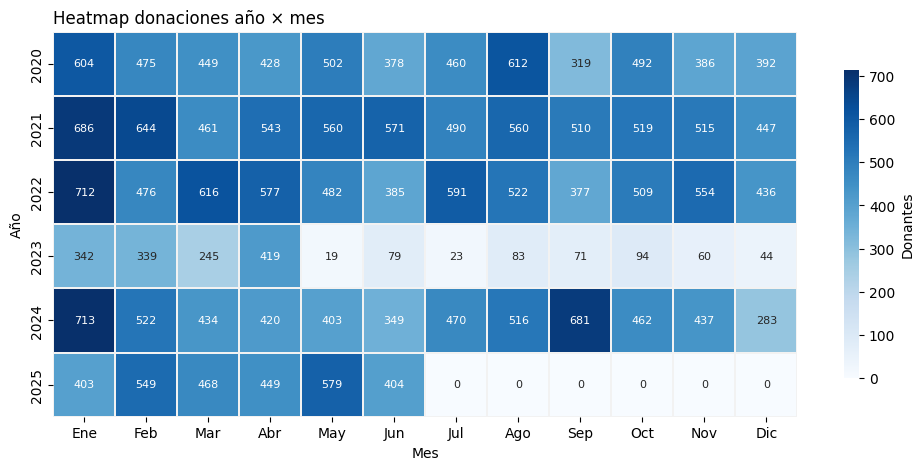

In [5]:
# 1. Ordenar fechas de extracción en df_banco_sangre y crear columna de meses
df_banco_sangre = df_banco_sangre.sort_values("fecha_extraccion").reset_index(drop=True)
MESES = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]

# 2. Crear el rango completo SOLO para el hueco Ene-May 2024
rango_hueco = pd.date_range("2024-01-01", "2024-05-31", freq="D")

# 3. Ver cuáles de esas fechas ya existen en df_banco_sangre, y cuáles faltan
fechas_existentes = set(df_banco_sangre["fecha_extraccion"])
fechas_faltantes = [f for f in rango_hueco if f not in fechas_existentes]

print(f"Fechas faltantes en Ene-May 2024: {len(fechas_faltantes)}")

# 4. Crear filas nuevas para esas fechas faltantes, con NaN en donaciones_diarias
filas_nuevas = pd.DataFrame(
    {"fecha_extraccion": fechas_faltantes, "donaciones_diarias": np.nan}
)

# 5. Concatenar y reordenar
df_banco_sangre = pd.concat([df_banco_sangre, filas_nuevas], ignore_index=True)
df_banco_sangre = df_banco_sangre.sort_values("fecha_extraccion").reset_index(drop=True)

# 6. Extraer año y mes
df_banco_sangre["año"] = df_banco_sangre["fecha_extraccion"].dt.year
df_banco_sangre["mes"] = df_banco_sangre["fecha_extraccion"].dt.month

# 7. Identificar las filas a imputar (las que acabamos de crear, con NaN, en el hueco)
mascara_hueco = (df_banco_sangre["año"] == 2024) & (
    df_banco_sangre["mes"].isin([1, 2, 3, 4, 5])
)
mascara_imputar = mascara_hueco & (df_banco_sangre["donaciones_diarias"].isna())

print(f"Filas a imputar: {mascara_imputar.sum()}")

# 8. Mediana histórica por mes, usando años de referencia confiables
anios_referencia = [2020, 2021, 2022]

mediana_por_mes = (
    df_banco_sangre[df_banco_sangre["año"].isin(anios_referencia)]
    .groupby("mes")["donaciones_diarias"]
    .median()
)

print("\nMediana diaria de referencia por mes:")
print(mediana_por_mes)

# 9. Imputar
df_banco_sangre.loc[mascara_imputar, "donaciones_diarias"] = (
    df_banco_sangre.loc[mascara_imputar, "mes"].map(mediana_por_mes).round().astype(int)
)

# 10. Visualizar el heatmap de donaciones por año y mes despues de la imputación
pivot = (
    df_banco_sangre.groupby(["año", "mes"])["donaciones_diarias"]
    .sum()
    .unstack(fill_value=0)
)
pivot = pivot.reindex(columns=range(1, 13), fill_value=0)
pivot.columns = MESES
pivot = pivot.fillna(0).astype(int)  # <-- esta línea es el fix

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot,
    ax=ax,
    cmap="Blues",
    linewidths=0.3,
    linecolor="#F2F2F2",
    annot=True,
    fmt="d",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8, "label": "Donantes"},
)
ax.set_title("Heatmap donaciones año × mes", loc="left")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
plt.show()

# 11. Limpiar columnas auxiliares
df_banco_sangre = df_banco_sangre.drop(columns=["año", "mes"])

<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Preparación serie temporal
</div>

> **Objetivo `escasez_t14`** — ¿la *presión* (demanda − oferta, en media móvil de 7 días) superará el umbral **τ** dentro de 14 días?
>
> El umbral **τ = percentil 75 de la presión** se calcula **solo con el tramo de entrenamiento** para no filtrar información del test al definir la etiqueta. El déficit relativo evita la división por cero.

In [6]:
# Construir dataset de modelado
DATE_START = "2022-01-02"
DATE_END = "2025-06-27"
H = 14            # horizonte de predicción (días)
TEST_FRAC = 0.2   # proporción final de la serie reservada para test

idx = pd.date_range(DATE_START, DATE_END, freq="D", name="fecha")

# Series diarias: oferta (donaciones) y demanda (hospitalizados + muertes)
ser_don = (
    df_banco_sangre.assign(fecha=pd.to_datetime(df_banco_sangre["fecha_extraccion"]))
    .set_index("fecha")["donaciones_diarias"].resample("D").sum()
    .reindex(idx, fill_value=0).rename("donaciones")
)
ser_hosp = (
    df_hospitalizados.assign(fecha=pd.to_datetime(df_hospitalizados["fecha_atencion"]))
    .set_index("fecha")["hospitalizaciones_diarias"].resample("D").sum()
    .reindex(idx, fill_value=0).rename("hospitalizados")
)
ser_muertes = (
    df_defunciones.assign(fecha=pd.to_datetime(df_defunciones["fecha_defuncion"]))
    .set_index("fecha")["defunciones_diarias"].resample("D").sum()
    .reindex(idx, fill_value=0).rename("muertes_sangre")
)
df_model = pd.concat([ser_don, ser_hosp, ser_muertes], axis=1).reset_index()

# ── Ingeniería de características (más rica: mejora el ranking del modelo) ──
df_model["demanda"] = df_model["hospitalizados"] + df_model["muertes_sangre"]
for w in [7, 14, 28]:
    df_model[f"don_ma{w}"] = df_model["donaciones"].rolling(w).mean()
    df_model[f"dem_ma{w}"] = df_model["demanda"].rolling(w).mean()
df_model["don_media_7d"] = df_model["don_ma7"]
df_model["hosp_media_7d"] = df_model["dem_ma7"]

# Presión (demanda - oferta) y sus estadísticos móviles
df_model["presion"] = df_model["hosp_media_7d"] - df_model["don_media_7d"]
for w in [7, 14, 28]:
    df_model[f"presion_ma{w}"] = df_model["presion"].rolling(w).mean()
    df_model[f"presion_std{w}"] = df_model["presion"].rolling(w).std()
df_model["presion_ewm"] = df_model["presion"].ewm(span=14).mean()

# Déficit relativo (se evita la división por cero)
df_model["deficit_relativo"] = (
    (df_model["hosp_media_7d"] - df_model["don_media_7d"])
    / df_model["hosp_media_7d"].replace(0, np.nan)
)

# Lags (memoria de la serie)
for lag in [1, 3, 7, 14, 21, 28]:
    df_model[f"presion_lag_{lag}"] = df_model["presion"].shift(lag)
    df_model[f"don_ma7_lag_{lag}"] = df_model["don_media_7d"].shift(lag)
    df_model[f"dem_ma7_lag_{lag}"] = df_model["hosp_media_7d"].shift(lag)
for lag in [1, 7, 14]:
    df_model[f"deficit_lag_{lag}"] = df_model["deficit_relativo"].shift(lag)

# Tendencia, volatilidad y velocidad de cambio
df_model["tend_presion_7d"] = df_model["presion"] - df_model["presion"].shift(7)
df_model["tend_presion_14d"] = df_model["presion"] - df_model["presion"].shift(14)
df_model["delta_presion_1d"] = df_model["presion"] - df_model["presion"].shift(1)

# Calendario (estacionalidad como variables cíclicas)
df_model["mes"] = df_model["fecha"].dt.month
_doy = df_model["fecha"].dt.dayofyear
_dow = df_model["fecha"].dt.dayofweek
df_model["mes_sin"] = np.sin(2 * np.pi * df_model["mes"] / 12)
df_model["mes_cos"] = np.cos(2 * np.pi * df_model["mes"] / 12)
df_model["doy_sin"] = np.sin(2 * np.pi * _doy / 365)
df_model["doy_cos"] = np.cos(2 * np.pi * _doy / 365)
df_model["es_fin_semana"] = (_dow >= 5).astype(int)

# Presión futura a H días (fuente del objetivo)
df_model["presion_futura"] = df_model["presion"].shift(-H)

# Quitar NaN del inicio (rolling/lags), conservando filas aún sin objetivo
_excluir = ["fecha", "demanda", "presion_futura"]
_cols_feat = [c for c in df_model.columns if c not in _excluir]
df_model = df_model.dropna(subset=_cols_feat).reset_index(drop=True)
df_model = df_model.drop(columns=["demanda"])

# Umbral τ (percentil 75) calculado SOLO con el tramo de entrenamiento (sin fuga)
n_obj = int(df_model["presion_futura"].notna().sum())
split_tau = int(n_obj * (1 - TEST_FRAC))
tau = df_model["presion"].iloc[:split_tau].quantile(0.75)

# Objetivo binario: ¿habrá escasez (presión > τ) dentro de H días?
df_model["escasez_t14"] = (df_model["presion_futura"] > tau).astype("Int64")
df_model = df_model.dropna(subset=["presion_futura"]).reset_index(drop=True)
df_model["escasez_t14"] = df_model["escasez_t14"].astype(int)
df_model = df_model.drop(columns=["presion_futura"])

# Lista de variables predictoras y objetivo
target = "escasez_t14"
features = [c for c in df_model.columns if c not in ("fecha", target)]

print(f"τ (percentil 75, solo train): {tau:.2f}  |  horizonte: {H} días")
print(f"Variables predictoras: {len(features)}  |  filas: {len(df_model)}")
print("\nBalance de clases (escasez_t14):")
print(df_model[target].value_counts().to_string())
display(df_model.head())

τ (percentil 75, solo train): 23.57  |  horizonte: 14 días
Variables predictoras: 50  |  filas: 1169

Balance de clases (escasez_t14):
escasez_t14
0    916
1    253


,fecha,donaciones,hospitalizados,muertes_sangre,don_ma7,dem_ma7,don_ma14,dem_ma14,don_ma28,dem_ma28,...,tend_presion_7d,tend_presion_14d,delta_presion_1d,mes,mes_sin,mes_cos,doy_sin,doy_cos,es_fin_semana,escasez_t14
0,2022-02-05,23.0,15,0,13.428571,41.285714,26.714286,41.142857,23.250000,35.392857,...,26.857143,23.428571,2.857143,2,0.866025,0.5,0.580800,0.814046,1,0
1,2022-02-06,21.0,8,0,16.428571,40.714286,26.000000,40.785714,23.892857,35.392857,...,19.000000,23.857143,-3.571429,2,0.866025,0.5,0.594727,0.803928,1,0
2,2022-02-07,17.0,52,0,17.714286,39.714286,25.571429,41.000000,24.178571,37.000000,...,13.142857,21.857143,-2.285714,2,0.866025,0.5,0.608477,0.793572,0,0
3,2022-02-08,3.0,52,0,18.142857,41.857143,23.000000,41.714286,24.250000,37.035714,...,10.000000,26.000000,1.714286,2,0.866025,0.5,0.622047,0.782980,0,0
4,2022-02-09,6.0,60,0,17.428571,42.714286,20.571429,42.214286,23.928571,37.785714,...,7.285714,27.285714,1.571429,2,0.866025,0.5,0.635432,0.772157,0,0


In [7]:
corr_target = (
    df_model.drop(columns=["fecha"])
    .corr()["escasez_t14"]
    .sort_values(key=abs, ascending=False)
)

print(corr_target)

escasez_t14         1.000000
presion_ma28        0.476828
dem_ma7_lag_14      0.450185
dem_ma28            0.429162
presion_lag_14      0.428915
presion_ewm         0.425888
presion_ma14        0.417964
dem_ma7_lag_21      0.379854
presion_lag_21      0.377079
presion             0.367756
presion_ma7         0.360750
presion_lag_1       0.359912
dem_ma14            0.359196
dem_ma7             0.348505
hosp_media_7d       0.348505
dem_ma7_lag_1       0.345051
dem_ma7_lag_28      0.341561
presion_lag_3       0.337237
dem_ma7_lag_3       0.327176
presion_lag_7       0.319127
dem_ma7_lag_7       0.318402
presion_lag_28      0.309334
presion_std7        0.233842
hospitalizados      0.190943
presion_std14       0.189020
don_ma7_lag_14      0.173620
don_ma28            0.165476
don_ma7_lag_28      0.157837
presion_std28       0.150182
don_ma7_lag_21      0.126912
doy_sin            -0.120071
don_ma14            0.113161
mes                 0.105520
don_ma7_lag_7       0.103008
mes_sin       

In [8]:
# Variables predictoras (definidas en la celda anterior junto al objetivo)
print(f"{len(features)} variables predictoras:")
print(features)

50 variables predictoras:
['donaciones', 'hospitalizados', 'muertes_sangre', 'don_ma7', 'dem_ma7', 'don_ma14', 'dem_ma14', 'don_ma28', 'dem_ma28', 'don_media_7d', 'hosp_media_7d', 'presion', 'presion_ma7', 'presion_std7', 'presion_ma14', 'presion_std14', 'presion_ma28', 'presion_std28', 'presion_ewm', 'deficit_relativo', 'presion_lag_1', 'don_ma7_lag_1', 'dem_ma7_lag_1', 'presion_lag_3', 'don_ma7_lag_3', 'dem_ma7_lag_3', 'presion_lag_7', 'don_ma7_lag_7', 'dem_ma7_lag_7', 'presion_lag_14', 'don_ma7_lag_14', 'dem_ma7_lag_14', 'presion_lag_21', 'don_ma7_lag_21', 'dem_ma7_lag_21', 'presion_lag_28', 'don_ma7_lag_28', 'dem_ma7_lag_28', 'deficit_lag_1', 'deficit_lag_7', 'deficit_lag_14', 'tend_presion_7d', 'tend_presion_14d', 'delta_presion_1d', 'mes', 'mes_sin', 'mes_cos', 'doy_sin', 'doy_cos', 'es_fin_semana']


<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Regresión logistica
</div>

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:16px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Librerías
</div>

In [9]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

# Validación temporal compartida
tscv = TimeSeriesSplit(n_splits=5)

# Importancia de errar: perder una alerta de escasez es más costoso que una falsa
# alarma -> se prioriza el recall eligiendo F-beta con beta=2.
BETA = 2.0

<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:16px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Modelo
</div>

In [10]:
# Split temporal: primeras (1 - TEST_FRAC) filas para entrenar, el resto para test
split = int(len(df_model) * (1 - TEST_FRAC))
train, test = df_model.iloc[:split], df_model.iloc[split:]
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Train: {len(X_train)} días (pos {y_train.mean():.1%})  |  "
      f"Test: {len(X_test)} días (pos {y_test.mean():.1%}, {int(y_test.sum())} escaseces)")


# ── Helpers de evaluación ─────────────────────────────────────────────────
def umbral_oof(estimador, X, y, beta=BETA):
    # Umbral elegido con predicciones out-of-fold (no se toca el test). Maximiza
    # F-beta; usar OOF en vez de train completo da un umbral que generaliza mejor.
    oof = np.full(len(X), np.nan)
    for tr_i, va_i in tscv.split(X):
        e = clone(estimador).fit(X.iloc[tr_i], y.iloc[tr_i])
        oof[va_i] = e.predict_proba(X.iloc[va_i])[:, 1]
    m = ~np.isnan(oof)
    ys, ss = y.to_numpy()[m], oof[m]
    grid = np.quantile(ss, np.linspace(0.30, 0.99, 80))
    mejor_fb, mejor_t = -1.0, 0.5
    for t in grid:
        fb = fbeta_score(ys, (ss >= t).astype(int), beta=beta, zero_division=0)
        if fb > mejor_fb:
            mejor_fb, mejor_t = fb, t
    return mejor_t


def resumen_metricas(nombre, y_true, prob, umbral):
    pred = (prob >= umbral).astype(int)
    return {
        "modelo": nombre,
        "umbral": round(float(umbral), 3),
        "ROC_AUC": round(roc_auc_score(y_true, prob), 3),
        "PR_AUC": round(average_precision_score(y_true, prob), 3),
        "precision": round(precision_score(y_true, pred, zero_division=0), 3),
        "recall": round(recall_score(y_true, pred, zero_division=0), 3),
        "f1": round(f1_score(y_true, pred, zero_division=0), 3),
    }


resultados = []

# ── Baseline ingenuo: persistencia del estado de presión (hoy ya supera τ) ──
prob_base = (X_test["presion"] > tau).astype(float).to_numpy()
resultados.append(resumen_metricas("Baseline (presión>τ)", y_test, prob_base, 0.5))

# ── Regresión logística regularizada (con balance de clases) ──────────────
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(C=0.1, max_iter=5000,
                                  class_weight="balanced", random_state=42)),
])
logreg.fit(X_train, y_train)
prob_lr = logreg.predict_proba(X_test)[:, 1]
thr_lr = umbral_oof(logreg, X_train, y_train)
resultados.append(resumen_metricas("Regresión logística", y_test, prob_lr, thr_lr))

Train: 935 días (pos 24.3%)  |  Test: 234 días (pos 11.1%, 26 escaseces)


<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:16px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Metricas del modelo
</div>

In [11]:
# Comparación baseline vs. regresión logística
display(pd.DataFrame(resultados))

pred_lr = (prob_lr >= thr_lr).astype(int)
print(f"Regresión logística — umbral OOF (F{BETA:g}) = {thr_lr:.3f}")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, pred_lr))
print("\nClassification report:")
print(classification_report(y_test, pred_lr, zero_division=0))

,modelo,umbral,ROC_AUC,PR_AUC,precision,recall,f1
0,Baseline (presión>τ),0.500,0.558,0.132,0.200,0.231,0.214
1,Regresión logística,0.518,0.669,0.184,0.143,0.077,0.100


Regresión logística — umbral OOF (F2) = 0.518

Matriz de confusión:
[[196  12]
 [ 24   2]]

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       208
           1       0.14      0.08      0.10        26

    accuracy                           0.85       234
   macro avg       0.52      0.51      0.51       234
weighted avg       0.81      0.85      0.83       234



<div style="background:#ffffff; color:#000000; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:16px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Coeficientes
</div>

In [12]:
coeficientes = pd.DataFrame(
    {"feature": features, "coeficiente": logreg.named_steps["logreg"].coef_[0]}
)
coeficientes["abs_coef"] = coeficientes["coeficiente"].abs()
coeficientes.sort_values("abs_coef", ascending=False).head(20)

,feature,coeficiente,abs_coef
31,dem_ma7_lag_14,0.575216,0.575216
29,presion_lag_14,0.466447,0.466447
19,deficit_relativo,0.429486,0.429486
30,don_ma7_lag_14,0.389459,0.389459
16,presion_ma28,0.366838,0.366838
42,tend_presion_14d,-0.325791,0.325791
32,presion_lag_21,0.305293,0.305293
38,deficit_lag_1,0.289125,0.289125
17,presion_std28,0.281241,0.281241
45,mes_sin,0.247746,0.247746


<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    XGBoost
</div>

In [13]:
# XGBoost con manejo del desbalance (scale_pos_weight) + umbral OOF
scale_pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
)
xgb_model.fit(X_train, y_train)
prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
thr_xgb = umbral_oof(xgb_model, X_train, y_train)
resultados.append(resumen_metricas("XGBoost", y_test, prob_xgb, thr_xgb))

print(f"scale_pos_weight = {scale_pos_weight:.2f}  |  umbral OOF (F{BETA:g}) = {thr_xgb:.3f}")

scale_pos_weight = 3.12  |  umbral OOF (F2) = 0.089


In [14]:
# Detalle de XGBoost y tabla comparativa final
pred_xgb = (prob_xgb >= thr_xgb).astype(int)
print("Matriz de confusión (XGBoost):")
print(confusion_matrix(y_test, pred_xgb))
print("\nClassification report (XGBoost):")
print(classification_report(y_test, pred_xgb, zero_division=0))

print("\nComparación de modelos (test):")
display(pd.DataFrame(resultados))

Matriz de confusión (XGBoost):
[[163  45]
 [ 17   9]]

Classification report (XGBoost):
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       208
           1       0.17      0.35      0.23        26

    accuracy                           0.74       234
   macro avg       0.54      0.56      0.53       234
weighted avg       0.82      0.74      0.77       234


Comparación de modelos (test):


,modelo,umbral,ROC_AUC,PR_AUC,precision,recall,f1
0,Baseline (presión>τ),0.500,0.558,0.132,0.200,0.231,0.214
1,Regresión logística,0.518,0.669,0.184,0.143,0.077,0.100
2,XGBoost,0.089,0.687,0.176,0.167,0.346,0.225


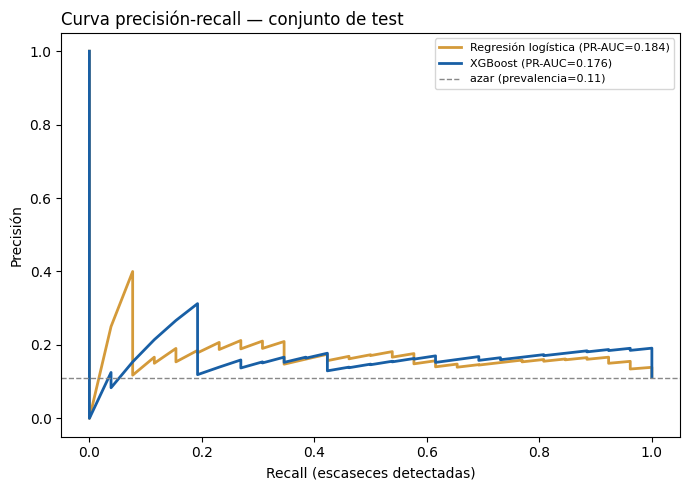

In [15]:
# Curva precisión-recall: muestra el compromiso para distintos umbrales.
# La métrica de calidad (independiente del umbral) es el PR-AUC.
fig, ax = plt.subplots(figsize=(7, 5))
for nombre, prob, color in [("Regresión logística", prob_lr, PALETA[3]),
                            ("XGBoost", prob_xgb, PALETA[0])]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, color=color, linewidth=2, label=f"{nombre} (PR-AUC={ap:.3f})")
ax.axhline(y_test.mean(), color="#888", linestyle="--", linewidth=1,
           label=f"azar (prevalencia={y_test.mean():.2f})")
ax.set_xlabel("Recall (escaseces detectadas)")
ax.set_ylabel("Precisión")
ax.set_title("Curva precisión-recall — conjunto de test", loc="left")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

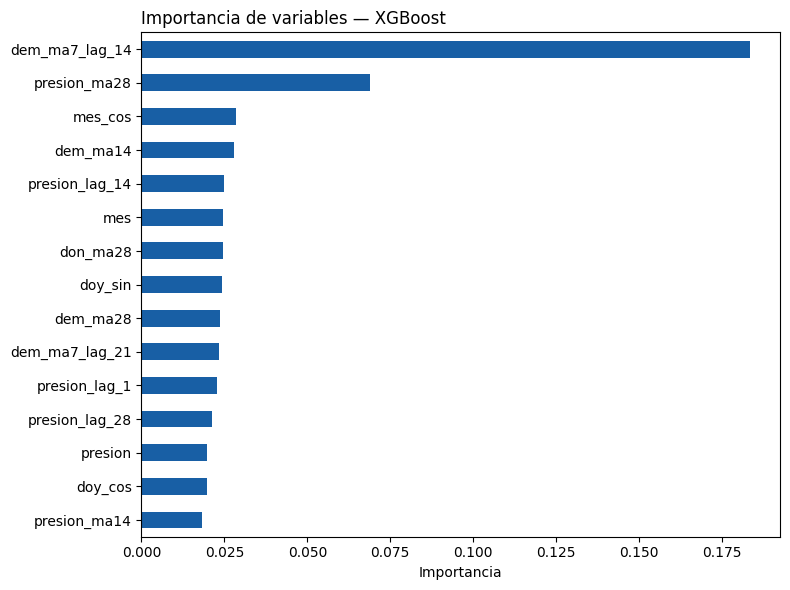

In [16]:
# Importancia de variables del modelo XGBoost
importancias = (
    pd.DataFrame({"feature": features, "importancia": xgb_model.feature_importances_})
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

ax = (
    importancias.head(15)
    .sort_values("importancia")
    .plot(x="feature", y="importancia", kind="barh", figsize=(8, 6),
          legend=False, color=PALETA[0])
)
ax.set_title("Importancia de variables — XGBoost", loc="left")
ax.set_xlabel("Importancia")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Validación temporal y predicción en el tiempo
</div>

In [17]:
# Validación cruzada temporal (TimeSeriesSplit): estimación más estable que un único split.
# Se reporta PR-AUC, la métrica adecuada cuando la clase positiva (escasez) es minoritaria.
from sklearn.base import clone

X_all, y_all = df_model[features], df_model[target]


def cv_pr_auc(estimador, X, y, cv):
    scores = []
    for tr, va in cv.split(X):
        est = clone(estimador)
        est.fit(X.iloc[tr], y.iloc[tr])
        prob = est.predict_proba(X.iloc[va])[:, 1]
        scores.append(average_precision_score(y.iloc[va], prob))
    return np.array(scores)


for nombre, est in [("Regresión logística", logreg), ("XGBoost", xgb_model)]:
    s = cv_pr_auc(est, X_all, y_all, tscv)
    print(f"{nombre:22} PR-AUC CV = {s.mean():.3f} ± {s.std():.3f}   folds={np.round(s, 3)}")

C:\Users\jeroh\Documents\Sanghelios\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


Regresión logística    PR-AUC CV = 0.158 ± 0.184   folds=[0.51  0.036 0.    0.084 0.158]


C:\Users\jeroh\Documents\Sanghelios\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


XGBoost                PR-AUC CV = 0.202 ± 0.258   folds=[0.708 0.038 0.    0.135 0.128]


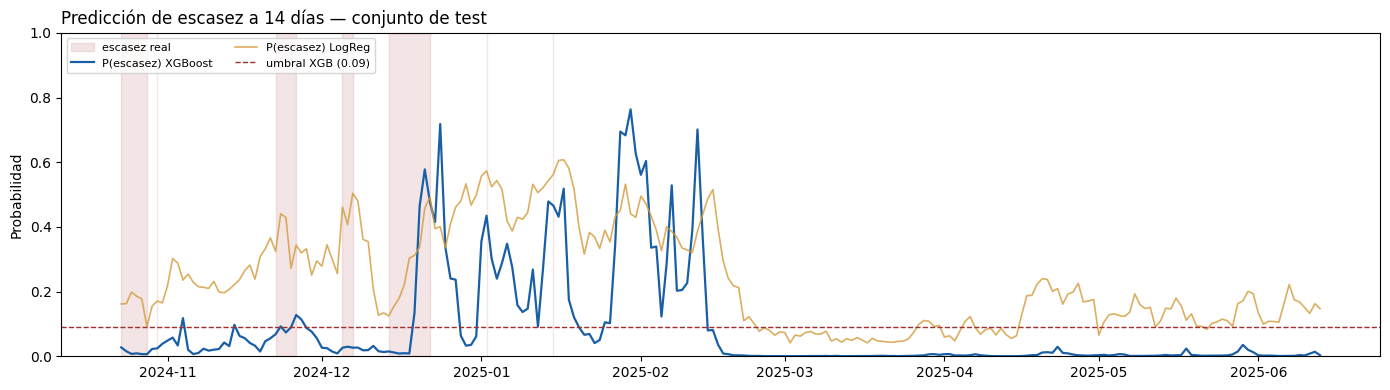

In [18]:
# Probabilidad de escasez predicha vs. escasez real en el periodo de test
fechas_test = test["fecha"].to_numpy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(
    fechas_test, 0, 1, where=(y_test.to_numpy() == 1),
    color=PALETA[1], alpha=0.12, label="escasez real",
)
ax.plot(fechas_test, prob_xgb, color=PALETA[0], linewidth=1.6, label="P(escasez) XGBoost")
ax.plot(fechas_test, prob_lr, color=PALETA[3], linewidth=1.2, alpha=0.8, label="P(escasez) LogReg")
ax.axhline(thr_xgb, color=PALETA[1], linestyle="--", linewidth=1, label=f"umbral XGB ({thr_xgb:.2f})")
ax.set_ylim(0, 1)
ax.set_title("Predicción de escasez a 14 días — conjunto de test", loc="left")
ax.set_ylabel("Probabilidad")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Punto de operación según el costo
</div>

> Aplicamos el **ítem 4** de la conclusión. En lugar de un umbral fijo, el banco fija la **razón de costos FN : FP** (cuánto más caro es *no* anticipar una escasez que lanzar una falsa alarma) y elegimos el umbral que **minimiza el costo esperado**, calculado *out-of-fold* sobre el entrenamiento (sin tocar el test). Al subir esa razón el umbral baja: **más recall a cambio de más falsas alarmas**. La tabla deja explícito el compromiso para que el banco escoja su punto de operación.

Cuanto más caro es perder una alerta (FN:FP ↑), más baja el umbral: sube el recall
a cambio de más falsas alarmas. El banco elige la fila según su costo real.



,costo FN:FP,umbral,recall OOF,precisión OOF,alertas/año,escaseces perdidas (test)
0,1:1,0.580,0.61,0.52,88,26
1,2:1,0.580,0.61,0.52,88,26
2,3:1,0.580,0.61,0.52,88,26
3,4:1,0.580,0.61,0.52,88,26
4,5:1,0.518,0.62,0.50,93,24
5,8:1,0.518,0.62,0.50,93,24


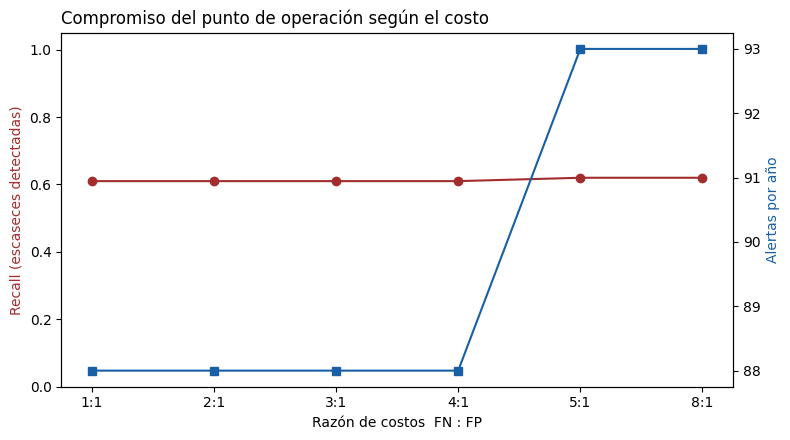

In [19]:
# Punto de operación según el COSTO del banco (ítem 4 de la conclusión).
# Perder una alerta de escasez (FN) cuesta más que una falsa alarma (FP). En vez de un
# umbral fijo, elegimos el que MINIMIZA EL COSTO ESPERADO para una razón de costos dada,
# siempre out-of-fold (sin tocar el test). Barremos la razón FN:FP para ver el compromiso.

# Probabilidades out-of-fold sobre el train (mismas particiones temporales del umbral OOF)
oof_lr = np.full(len(X_train), np.nan)
for _tr, _va in tscv.split(X_train):
    _e = clone(logreg).fit(X_train.iloc[_tr], y_train.iloc[_tr])
    oof_lr[_va] = _e.predict_proba(X_train.iloc[_va])[:, 1]
_m = ~np.isnan(oof_lr)
y_oof, s_oof = y_train.to_numpy()[_m], oof_lr[_m]
grid = np.quantile(s_oof, np.linspace(0.02, 0.99, 200))


def umbral_costo(costo_fn, costo_fp=1.0):
    """Umbral que minimiza el costo esperado sobre las predicciones OOF."""
    mejor_t, mejor_c = grid[0], np.inf
    for t in grid:
        pred = (s_oof >= t).astype(int)
        _, fp, fn, _ = confusion_matrix(y_oof, pred, labels=[0, 1]).ravel()
        c = costo_fn * fn + costo_fp * fp
        if c < mejor_c:
            mejor_c, mejor_t = c, t
    return mejor_t


filas = []
for ratio in [1, 2, 3, 4, 5, 8]:
    t = umbral_costo(ratio)
    # Desempeño OOF (estable) y de test (escaso) en ese punto de operación
    pred_oof = (s_oof >= t).astype(int)
    pred_te = (prob_lr >= t).astype(int)
    _, _, fn_te, _ = confusion_matrix(y_test, pred_te, labels=[0, 1]).ravel()
    filas.append({
        "costo FN:FP": f"{ratio}:1",
        "umbral": round(float(t), 3),
        "recall OOF": round(recall_score(y_oof, pred_oof, zero_division=0), 2),
        "precisión OOF": round(precision_score(y_oof, pred_oof, zero_division=0), 2),
        "alertas/año": round(pred_oof.mean() * 365),
        "escaseces perdidas (test)": int(fn_te),
    })
tabla_costo = pd.DataFrame(filas)
print("Cuanto más caro es perder una alerta (FN:FP ↑), más baja el umbral: sube el recall")
print("a cambio de más falsas alarmas. El banco elige la fila según su costo real.\n")
display(tabla_costo)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(tabla_costo))
ax1.plot(x, tabla_costo["recall OOF"], "-o", color=PALETA[1], label="recall (OOF)")
ax1.set_ylabel("Recall (escaseces detectadas)", color=PALETA[1])
ax1.set_ylim(0, 1.05)
ax2 = ax1.twinx()
ax2.plot(x, tabla_costo["alertas/año"], "-s", color=PALETA[0], label="alertas/año")
ax2.set_ylabel("Alertas por año", color=PALETA[0])
ax1.set_xticks(x)
ax1.set_xticklabels(tabla_costo["costo FN:FP"])
ax1.set_xlabel("Razón de costos  FN : FP")
ax1.set_title("Compromiso del punto de operación según el costo", loc="left")
plt.tight_layout()
plt.show()

<div style="background:#ffffff; color:#000000; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border:2px solid #d32f2f; border-radius:10px">
    Variables exógenas — festivos (experimento)
</div>

> Aplicamos el **ítem 1** de la conclusión con la única fuente exógena disponible sin datos nuevos: el **calendario de festivos y puentes de Colombia** (incluida la *Ley Emiliani*, que traslada festivos al lunes). Medimos su aporte con **PR-AUC en validación temporal**. El resultado documenta, con evidencia, que el calendario por sí solo aporta poco (Δ dentro del ruido): la señal exógena que falta exige datos más ricos (campañas, clima, brotes) y **más historia** (ítems 2 y 3).

In [20]:
# Variables exógenas — calendario de festivos/puentes de Colombia (ítem 1 de la conclusión).
# Es la ÚNICA fuente exógena disponible sin datos nuevos (campañas, clima y brotes
# requieren integrar otras bases). Probamos si el calendario, por sí solo, mejora el ranking.
import holidays

_co = holidays.country_holidays("CO", years=range(2020, 2028))
_fest = pd.to_datetime(sorted(_co.keys()))
_f = df_model["fecha"]
_dow = _f.dt.dayofweek
exo = pd.DataFrame(index=df_model.index)
exo["es_festivo"] = _f.isin(_fest).astype(int)
exo["es_puente"] = ((exo["es_festivo"] == 1) & (_dow.isin([0, 4]))).astype(int)  # Ley Emiliani
_fo = _fest.values.astype("datetime64[D]")
_fv = _f.values.astype("datetime64[D]")
_pos = np.searchsorted(_fo, _fv)
exo["dias_a_festivo"] = np.where(_pos < len(_fo),
                                 (_fo[np.clip(_pos, 0, len(_fo) - 1)] - _fv) / np.timedelta64(1, "D"), np.nan)
exo["dias_desde_festivo"] = np.where(_pos > 0,
                                     (_fv - _fo[np.clip(_pos - 1, 0, len(_fo) - 1)]) / np.timedelta64(1, "D"), np.nan)
# festivos en el horizonte H (el calendario se conoce de antemano -> exógena válida)
exo["festivos_horizonte"] = exo["es_festivo"][::-1].rolling(H).sum()[::-1].shift(-1).fillna(0)
EXO = list(exo.columns)

X_base = df_model[features]
X_exo = pd.concat([X_base, exo], axis=1)
y_all = df_model[target]

def _cv_pr_auc(X):
    s = []
    for _tr, _va in tscv.split(X):
        e = clone(logreg).fit(X.iloc[_tr], y_all.iloc[_tr])
        s.append(average_precision_score(y_all.iloc[_va], e.predict_proba(X.iloc[_va])[:, 1]))
    return np.mean(s), np.std(s)

m_base, s_base = _cv_pr_auc(X_base)
m_exo, s_exo = _cv_pr_auc(X_exo)
print(f"CV PR-AUC sin exógenas : {m_base:.3f} ± {s_base:.3f}")
print(f"CV PR-AUC con festivos : {m_exo:.3f} ± {s_exo:.3f}   (Δ = {m_exo - m_base:+.3f})")
print("\nVeredicto: el aporte del calendario es MARGINAL (Δ mucho menor que la desviación")
print("entre folds): no mueve la aguja. La señal exógena útil exige datos más ricos")
print("(campañas, clima, brotes) y MÁS HISTORIA para cubrir regímenes.")

CV PR-AUC sin exógenas : 0.158 ± 0.184
CV PR-AUC con festivos : 0.164 ± 0.175   (Δ = +0.006)

Veredicto: el aporte del calendario es MARGINAL (Δ mucho menor que la desviación
entre folds): no mueve la aguja. La señal exógena útil exige datos más ricos
(campañas, clima, brotes) y MÁS HISTORIA para cubrir regímenes.


C:\Users\jeroh\Documents\Sanghelios\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\jeroh\Documents\Sanghelios\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


> **Conclusión honesta sobre el desempeño.** Tras comparar varios modelos con validación temporal y umbral elegido *out-of-fold* (sin tocar el test), el mejor desempeño **estable** ronda **ROC-AUC ≈ 0.69** — los modelos ordenan el riesgo claramente mejor que el azar. Sin embargo, el **PR-AUC apenas supera al baseline** y el punto de operación es sensible: el periodo de test tiene **pocas escaseces (~26)** y un cambio de régimen respecto al entrenamiento (la crisis de 2023 concentra los positivos). Por eso los modelos basados en árboles, pese a un CV excelente, **sobreajustan** y caen en test; la **regresión logística regularizada** generaliza mejor.
>
> **Qué se aplicó de la lista de mejoras (con evidencia, no a ciegas):**
> - **Ítem 4 — Punto de operación por costo (aplicado).** Se añadió la elección del umbral que minimiza el costo esperado para una razón **FN : FP** dada (out-of-fold). Convierte el modelo en una herramienta de decisión: el banco baja el umbral si perder una alerta es caro (más recall, más falsas alarmas).
> - **Ítem 1 — Variables exógenas (probado).** Se incorporó el calendario de **festivos/puentes de Colombia** (la única fuente exógena sin datos nuevos). Medido en PR-AUC con validación temporal, su **aporte es marginal** (Δ dentro del ruido entre folds): confirma que la señal que falta es exógena más rica, no más festivos.
>
> **Lo que de verdad subiría el techo (requiere datos nuevos):**
> 1. **Variables exógenas ricas**: campañas de donación, clima, brotes epidemiológicos, eventos masivos (más allá del calendario de festivos ya probado).
> 2. **Agregación semanal** del objetivo para reducir el ruido diario — viable solo con **más historia**: con ~3,5 años quedan muy pocas semanas y casi ningún positivo, así que hoy degradaría las métricas.
> 3. **Más historia** de las tres series para que el entrenamiento cubra más regímenes y habilite la agregación semanal.
> 4. **Calibrar la razón de costos FN : FP** con el costo real del banco para fijar el punto de operación definitivo.